Scored dataset, no leakage, Random Forest

X = Morgan fingerprints, 2048 bits & ProtBERT 1024 bits

y = pChEMBL values

In [7]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rdkit

import sys
sys.path.append("/content/drive/MyDrive/CompDReAM/src")

# Core libraries
import pandas as pd
import numpy as np
import json
import time
import requests
import os
import glob
from tqdm import tqdm
from math import sqrt
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, r2_score, roc_auc_score, f1_score)
from sklearn.base import clone
import joblib

# PyTorch (ProtBERT)
import torch
from torch.utils.data import DataLoader

# Transformers (ProtBERT)
from transformers import BertTokenizer, BertModel

# Visual
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from tqdm import tqdm

generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = generator.GetFingerprint(mol)
        arr = np.zeros((1,), dtype=int)
        ConvertToNumpyArray(fp, arr)
        return arr
    return None

def fetch_uniprot_sequences(uniprot_ids, delay=0.5):
    base_url = "https://rest.uniprot.org/uniprotkb/"
    headers = {"accept": "application/json"}
    params = {"fields": ["sequence"]}
    id_to_sequence = {}
    for uid in tqdm(uniprot_ids):
        url = base_url + uid
        try:
            response = requests.get(url, headers=headers, params=params)
            if response.ok:
                seq = response.json().get("sequence", {}).get("value", "")
                if seq:
                    id_to_sequence[uid] = seq
            else:
                print(f"[!] Failed for {uid}: {response.status_code}")
        except Exception as e:
            print(f"[!] Error fetching {uid}: {str(e)}")
        time.sleep(delay)
    return id_to_sequence

def batch_embed_sequences(sequences, batch_size=128, max_length=1024, cache_prefix="/content/drive/MyDrive/CompDReAM/protbert/protbert_batch"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
    model = BertModel.from_pretrained("Rostlab/prot_bert").to(device).eval()
    spaced_seqs = [' '.join(list(seq)) for seq in sequences]
    embeddings = []
    for i in tqdm(range(0, len(spaced_seqs), batch_size), desc="Embedding sequences"):
        batch_path = f"{cache_prefix}_{i//batch_size}.npy"
        if os.path.exists(batch_path):
            continue  # already saved
        batch_seqs = spaced_seqs[i:i+batch_size]
        tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            outputs = model(**tokens)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        np.save(batch_path, batch_embeddings)
    print("✓ All batches embedded and saved to disk.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
base_dir = "/content/drive/MyDrive/CompDReAM/v3"
os.makedirs(base_dir, exist_ok=True)

df = pd.read_csv("/content/drive/MyDrive/CompDReAM/training_dataset.csv", low_memory=False)
df = df.dropna(subset=["Canonical SMILES", "UniProt", "pChEMBL"]).reset_index(drop=True)
model_path = os.path.join(base_dir, "rf_model.pkl")

fps, valid_idx = [], []
for idx, s in enumerate(df["Canonical SMILES"]):
    arr = smiles_to_morgan_fp(s)
    if arr is not None:
        fps.append(arr)
        valid_idx.append(idx)

df = df.iloc[valid_idx].reset_index(drop=True)
X_mol = np.array(fps)

# Process UniProt IDs
all_uniprots = df["UniProt"].dropna().str.split(",").explode().str.strip().unique().tolist()
cache_file = "/content/drive/MyDrive/CompDReAM/id_to_seq.json"

if os.path.exists(cache_file):
    print(f"✓ Loading sequences from cache: {cache_file}")
    with open(cache_file) as f:
        id_to_seq = json.load(f)
else:
    print("✗ Cache not found — fetching sequences from UniProt API...")
    id_to_seq = fetch_uniprot_sequences(all_uniprots)
    with open(cache_file, "w") as f:
        json.dump(id_to_seq, f)
    print(f"✓ Sequences fetched and saved to: {cache_file}")

# Map sequences to dataframe
df["UniProt_List"] = df["UniProt"].str.split(",").apply(lambda lst: [i.strip() for i in lst])
df["BestUniProt"] = df["UniProt_List"].apply(lambda lst: lst[0])
df["Sequence"] = df["BestUniProt"].map(id_to_seq)
valid_seq_mask = df["Sequence"].notna()

# Embedding
sequences = df.loc[valid_seq_mask, "Sequence"].tolist()
prot_cache_path = os.path.join(base_dir, "X_prot.npy")
batch_prefix = os.path.join(base_dir, "protbert", "protbert_batch")
batch_files = sorted(glob.glob(f"{batch_prefix}_*.npy"))

if batch_files:
    sample = np.load(batch_files[0], mmap_mode="r")
    dim = sample.shape[1]
    total_rows = sum(np.load(f, mmap_mode="r").shape[0] for f in batch_files)
else:
    dim, total_rows = None, None

if os.path.exists(prot_cache_path):
    print(f"✓ Loaded final cached embeddings: {prot_cache_path}")
    X_prot = np.memmap(prot_cache_path, dtype='float32', mode='r', shape=(total_rows, dim))
    if isinstance(X_prot[0], np.ndarray):
        X_prot = np.vstack(X_prot).astype(np.float32)
else:
    if batch_files:
        print(f"✓ Found {len(batch_files)} cached batches. Merging...")
        X_prot_memmap = np.memmap(prot_cache_path, dtype='float32', mode='w+', shape=(total_rows, dim))
        i = 0
        for path in tqdm(batch_files, desc="Merging batches"):
            batch = np.load(path, mmap_mode="r")
            X_prot_memmap[i:i+batch.shape[0], :] = batch
            i += batch.shape[0]
        del X_prot_memmap
        X_prot = np.memmap(prot_cache_path, dtype='float32', mode='r', shape=(total_rows, dim))
    else:
        print("✗ No batches found — computing ProtBERT embeddings...")
        batch_embed_sequences(sequences, cache_prefix=batch_prefix)
        # After computing, merge and reload as above...

df = df.loc[valid_seq_mask].reset_index(drop=True)
X_mol = X_mol[valid_seq_mask.values]
y = df["pChEMBL"].astype(float).values

# Combine features
X_combined_path = os.path.join(base_dir, "X_combined.npy")
y_path = os.path.join(base_dir, "y.npy")
n_samples = X_mol.shape[0]
combined_shape = (n_samples, X_mol.shape[1] + X_prot.shape[1])

if os.path.exists(X_combined_path) and os.path.exists(y_path):
    print("✓ Loading existing X and y from disk.")
    X = np.memmap(X_combined_path, dtype=np.float32, mode="r", shape=combined_shape)
    y = np.load(y_path)
else:
    print("✗ No cache found — writing feature arrays (fast)...")
    X_concat = np.concatenate([X_mol, X_prot], axis=1).astype(np.float32)
    np.save(X_combined_path, X_concat)
    np.save(y_path, y)
    print("✓ Features and labels saved to .npy")
    X = np.load(X_combined_path, mmap_mode="r")  # Load with memmap mode if needed

# Train-test split using unique pairs
df["pair"] = df["Canonical SMILES"] + "_" + df["BestUniProt"]
unique_pairs = df.drop_duplicates(subset="pair")
train_pairs, test_pairs = train_test_split(unique_pairs["pair"], test_size=0.2, random_state=42)
train_df = df[df["pair"].isin(train_pairs)]
test_df = df[df["pair"].isin(test_pairs)]

assert len(set(train_df["pair"]) & set(test_df["pair"])) == 0

# Split features
X_train = X[train_df.index]
y_train = y[train_df.index]
X_test = X[test_df.index]
y_test = y[test_df.index]

# Train or load model
if os.path.exists(model_path):
    print("✓ Loading pre-trained model...")
    rf = joblib.load(model_path)
else:
    print("✗ No pre-trained model found. Training now...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    joblib.dump(rf, model_path)
    print(f"✓ Model saved to: {model_path}")

# Evaluate
y_pred = rf.predict(X_test)
print("Train R²:", rf.score(X_train, y_train))
print("Test R²:", r2_score(y_test, y_pred))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))

[17:53:07] WARNING: not removing hydrogen atom without neighbors


✓ Loading sequences from cache: /content/drive/MyDrive/CompDReAM/id_to_seq.json
✓ Loaded final cached embeddings: /content/drive/MyDrive/CompDReAM/v3/X_prot.npy
✓ Loading existing X and y from disk.
✓ Loading pre-trained model...
Train R²: 0.9376731379360037
Test R²: 0.7262633072577005
RMSE: 0.5245307238636852


In [19]:
metadata = {
    "model": "RandomForestRegressor",
    "timestamp": datetime.now().isoformat(),
    "n_estimators": 100,
    "random_state": 42,
    "train_r2": rf.score(X_train, y_train),
    "test_r2": r2_score(y_test, y_pred),
    "rmse": sqrt(mean_squared_error(y_test, y_pred)),
    "n_samples": X.shape[0],
    "feature_dim": X.shape[1],
    "model_path": model_path
}
pd.DataFrame([metadata]).to_csv("/content/drive/MyDrive/CompDReAM/v3/rf_metadata_summary.csv", index=False)
print(f"✓ Metadata saved to rf_metadata_summary.csv")

✓ Metadata saved to rf_metadata_summary.csv


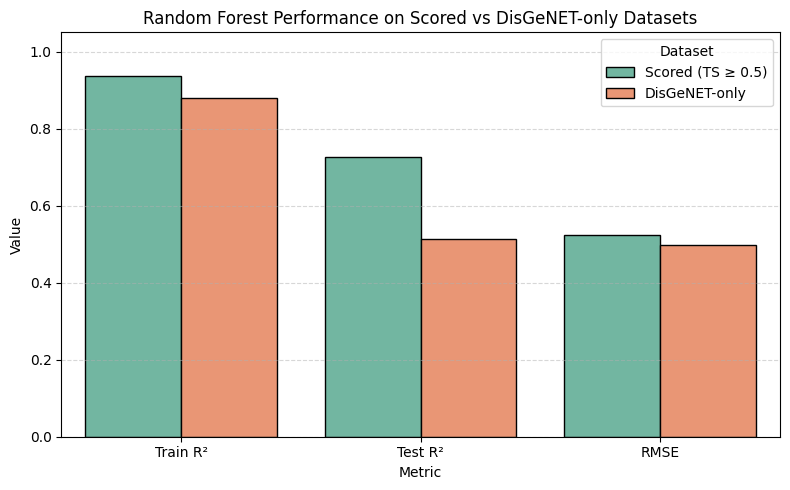

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === Performance metrics for v3 and v4 ===
data = {
    "Dataset": ["Scored (TS ≥ 0.5)", "Scored (TS ≥ 0.5)", "Scored (TS ≥ 0.5)",
                "DisGeNET-only", "DisGeNET-only", "DisGeNET-only"],
    "Metric": ["Train R²", "Test R²", "RMSE"] * 2,
    "Value": [0.9377, 0.7263, 0.5245, 0.8798, 0.5128, 0.4966]
}

df_perf = pd.DataFrame(data)

# === Plotting ===
plt.figure(figsize=(8, 5))
sns.barplot(data=df_perf, x="Metric", y="Value", hue="Dataset", palette="Set2", edgecolor="black")

plt.title("Random Forest Performance on Scored vs DisGeNET-only Datasets")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


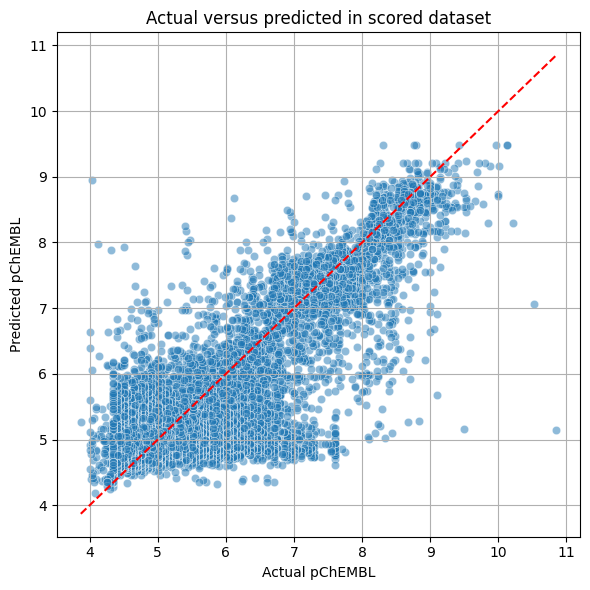

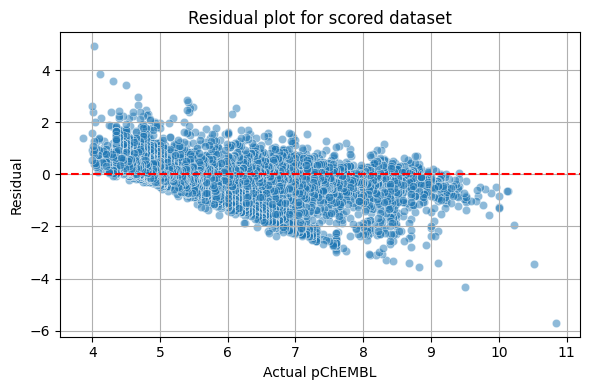

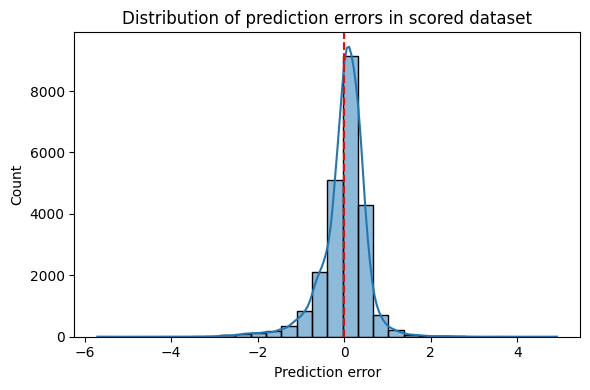

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_actual_vs_pred(y_test, y_pred, label):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red')
    plt.xlabel("Actual pChEMBL")
    plt.ylabel("Predicted pChEMBL")
    plt.title(f"Actual versus predicted in {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_error_histogram(y_test, y_pred, label):
    errors = y_pred - y_test
    plt.figure(figsize=(6, 4))
    sns.histplot(errors, bins=30, kde=True)
    plt.axvline(0, color="red", linestyle="--")
    plt.title(f"Distribution of prediction errors in {label}")
    plt.xlabel("Prediction error")
    plt.tight_layout()
    plt.show()

def plot_residuals(y_test, y_pred, label):
    residuals = y_pred - y_test
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=residuals, alpha=0.5)
    plt.axhline(0, linestyle='--', color='red')
    plt.xlabel("Actual pChEMBL")
    plt.ylabel("Residual")
    plt.title(f"Residual plot for {label}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_actual_vs_pred(y_test, y_pred, label="scored dataset")
plot_residuals(y_test, y_pred, label="scored dataset")
plot_error_histogram(y_test, y_pred, "scored dataset")

In [21]:
base_dir = "/content/drive/MyDrive/CompDReAM/v3.5"  # data leakage, scored dataset, RF
os.makedirs(base_dir, exist_ok=True)

df = pd.read_csv("/content/drive/MyDrive/CompDReAM/training_dataset.csv", low_memory=False)
df = df.dropna(subset=["Canonical SMILES", "UniProt", "pChEMBL"]).reset_index(drop=True)
model_path = os.path.join(base_dir, "rf_model.pkl")

fps, valid_idx = [], []
for idx, s in enumerate(df["Canonical SMILES"]):
    arr = smiles_to_morgan_fp(s)
    if arr is not None:
        fps.append(arr)
        valid_idx.append(idx)

df = df.iloc[valid_idx].reset_index(drop=True)
X_mol = np.array(fps)

# Process UniProt IDs
all_uniprots = df["UniProt"].dropna().str.split(",").explode().str.strip().unique().tolist()
cache_file = "/content/drive/MyDrive/CompDReAM/id_to_seq.json"

if os.path.exists(cache_file):
    print(f"✓ Loading sequences from cache: {cache_file}")
    with open(cache_file) as f:
        id_to_seq = json.load(f)
else:
    print("✗ Cache not found — fetching sequences from UniProt API...")
    id_to_seq = fetch_uniprot_sequences(all_uniprots)
    with open(cache_file, "w") as f:
        json.dump(id_to_seq, f)
    print(f"✓ Sequences fetched and saved to: {cache_file}")

# Map sequences to dataframe
df["UniProt_List"] = df["UniProt"].str.split(",").apply(lambda lst: [i.strip() for i in lst])
df["BestUniProt"] = df["UniProt_List"].apply(lambda lst: lst[0])
df["Sequence"] = df["BestUniProt"].map(id_to_seq)
valid_seq_mask = df["Sequence"].notna()

# Embedding
sequences = df.loc[valid_seq_mask, "Sequence"].tolist()
prot_cache_path = os.path.join(base_dir, "X_prot.npy")
batch_prefix = "/content/drive/MyDrive/CompDReAM/v3/protbert/protbert_batch"
batch_files = sorted(glob.glob(f"{batch_prefix}_*.npy"))

if batch_files:
    sample = np.load(batch_files[0], mmap_mode="r")
    dim = sample.shape[1]
    total_rows = sum(np.load(f, mmap_mode="r").shape[0] for f in batch_files)
else:
    dim, total_rows = None, None

if os.path.exists(prot_cache_path):
    print(f"✓ Loaded final cached embeddings: {prot_cache_path}")
    X_prot = np.memmap(prot_cache_path, dtype='float32', mode='r', shape=(total_rows, dim))
    if isinstance(X_prot[0], np.ndarray):
        X_prot = np.vstack(X_prot).astype(np.float32)
else:
    if batch_files:
        print(f"✓ Found {len(batch_files)} cached batches. Merging...")
        X_prot_memmap = np.memmap(prot_cache_path, dtype='float32', mode='w+', shape=(total_rows, dim))
        i = 0
        for path in tqdm(batch_files, desc="Merging batches"):
            batch = np.load(path, mmap_mode="r")
            X_prot_memmap[i:i+batch.shape[0], :] = batch
            i += batch.shape[0]
        del X_prot_memmap
        X_prot = np.memmap(prot_cache_path, dtype='float32', mode='r', shape=(total_rows, dim))
    else:
        print("✗ No batches found — computing ProtBERT embeddings...")
        batch_embed_sequences(sequences, cache_prefix=batch_prefix)
        # After computing, merge and reload as above...

df = df.loc[valid_seq_mask].reset_index(drop=True)
X_mol = X_mol[valid_seq_mask.values]
y = df["pChEMBL"].astype(float).values

# Combine features
X_combined_path = os.path.join(base_dir, "X_combined.npy")
y_path = os.path.join(base_dir, "y.npy")
n_samples = X_mol.shape[0]
combined_shape = (n_samples, X_mol.shape[1] + X_prot.shape[1])

if os.path.exists(X_combined_path) and os.path.exists(y_path):
    print("✓ Loading existing X and y from disk.")
    X = np.memmap(X_combined_path, dtype=np.float32, mode="r", shape=combined_shape)
    y = np.load(y_path)
else:
    print("✗ No cache found — writing feature arrays (fast)...")
    X_concat = np.concatenate([X_mol, X_prot], axis=1).astype(np.float32)
    np.save(X_combined_path, X_concat)
    np.save(y_path, y)
    print("✓ Features and labels saved to .npy")
    X = np.load(X_combined_path, mmap_mode="r")  # Load with memmap mode if needed

# Train-test split with data leakage allowed (random row-wise)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Split features
X_train = X[train_df.index]
y_train = y[train_df.index]
X_test = X[test_df.index]
y_test = y[test_df.index]

# Train or load model
if os.path.exists(model_path):
    print("✓ Loading pre-trained model...")
    rf = joblib.load(model_path)
else:
    print("✗ No pre-trained model found. Training now...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    joblib.dump(rf, model_path)
    print(f"✓ Model saved to: {model_path}")

# Evaluate
y_pred = rf.predict(X_test)
print("Train R²:", rf.score(X_train, y_train))
print("Test R²:", r2_score(y_test, y_pred))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))

[19:19:45] WARNING: not removing hydrogen atom without neighbors


✓ Loading sequences from cache: /content/drive/MyDrive/CompDReAM/id_to_seq.json
✓ Loaded final cached embeddings: /content/drive/MyDrive/CompDReAM/v3.5/X_prot.npy
✓ Loading existing X and y from disk.
✗ No pre-trained model found. Training now...
✓ Model saved to: /content/drive/MyDrive/CompDReAM/v3.5/rf_model.pkl
Train R²: 0.9411274359944701
Test R²: 0.7391590653113509
RMSE: 0.5186497753369085
